SAMPLE: Hightouch take-home EDA (live review)

Public SAMPLE send data. Not a customer warehouse. Not Black Clover.

Walk this like a marketer is on the call: incrementality, counterfactual, cohorts, send volume / reachability. Last cell is the ship/kill paragraph.

No PyTorch. No SHAP. No reward-function agent.

In [1]:
from pathlib import Path

from IPython.display import Image, display

from generate_sends import main as generate_main
from analysis import (
    CLEAN_CSV,
    DIRTY_CSV,
    OUT,
    arm_summary,
    cohort_summary,
    lift_metrics,
    load_sends,
    plot_lift,
    run_sql_incremental_cr,
    write_marketer,
)

OUT.mkdir(parents=True, exist_ok=True)
if not CLEAN_CSV.exists() or not DIRTY_CSV.exists():
    generate_main()

clean_df = load_sends(CLEAN_CSV)
dirty_df = load_sends(DIRTY_CSV)
print(clean_df.shape, clean_df.columns)
clean_df.head()

(12000, 7) ['user_id', 'cohort_week', 'channel', 'sent', 'converted', 'revenue', 'holdout_flag']


user_id,cohort_week,channel,sent,converted,revenue,holdout_flag
i64,str,str,i64,i64,f64,i64
1,"""2024-01-01""","""email""",1,0,0.0,0
2,"""2024-01-01""","""email""",1,0,0.0,0
3,"""2024-01-01""","""email""",0,0,0.0,1
4,"""2024-01-01""","""email""",1,0,0.0,0
5,"""2024-01-01""","""email""",0,0,0.0,0


## Assignment and reachability

`holdout_flag=1` is the counterfactual (should not receive email). `sent` is what the ESP actually did. Treated sent-rate is below 100% because of reachability and a weekly send cap — that is ITT, the policy you can run. Holdout sent-rate on a clean file should be ~0.

In [2]:
arms = arm_summary(clean_df)
arms

holdout_flag,n,n_sent,sent_rate,conversions,cr,revenue,revenue_per_user
i64,u32,i64,f64,i64,f64,f64,f64
0,7200,5600,0.777778,459,0.06375,23961.65,3.328007
1,4800,0,0.0,206,0.042917,10065.33,2.096944


## Incremental conversion rate (ITT)

Treated vs holdout, 4-week window. Wilson interval on each arm’s CR. Bootstrap percentile interval on the difference (seed 2020, 2000 resamples). Do not score this as sent vs unsent — that is not the experiment.

In [3]:
clean = lift_metrics(clean_df, "sends.csv")
clean

{'dataset': 'sends.csv',
 'treated_n': 7200,
 'holdout_n': 4800,
 'treated_sent_rate': 0.7777777777777778,
 'holdout_sent_rate': 0.0,
 'treated_cr': 0.06375,
 'holdout_cr': 0.042916666666666665,
 'treated_cr_wilson_low': 0.058336144798167906,
 'treated_cr_wilson_high': 0.069629134171875,
 'holdout_cr_wilson_low': 0.03753929548815217,
 'holdout_cr_wilson_high': 0.049025090814676806,
 'incremental_cr': 0.020833333333333336,
 'incremental_cr_ci_low': 0.012845486111111108,
 'incremental_cr_ci_high': 0.028819444444444446,
 'ci_method': 'bootstrap_percentile_B2000_seed2020',
 'treated_revenue': 23961.65,
 'holdout_revenue': 10065.329999999998,
 'treated_rev_per_user': 3.3280069444444447,
 'holdout_rev_per_user': 2.0969437499999994,
 'incremental_rev_per_user': 1.2310631944444452}

## Cohort revenue, 4-week window

`cohort_week × holdout_flag`. Outcomes on the file are already 4-week post-send cash and conversions. If incremental cash piles into one week, do not nationalize always-on (see `out/experiment_design.md`).

In [4]:
cohort = cohort_summary(clean_df)
cohort.select(
    "cohort_week",
    "n",
    "cr",
    "revenue",
    "n_holdout",
    "cr_holdout",
    "revenue_holdout",
    "incremental_cr",
    "incremental_revenue",
)

cohort_week,n,cr,revenue,n_holdout,cr_holdout,revenue_holdout,incremental_cr,incremental_revenue
str,u32,f64,f64,u32,f64,f64,f64,f64
"""2024-01-01""",891,0.143659,6950.15,609,0.078818,2104.96,0.064841,4845.19
"""2024-01-08""",909,0.057206,2572.79,591,0.047377,1393.29,0.009828,1179.5
"""2024-01-15""",910,0.052747,2516.13,590,0.037288,1073.89,0.015459,1442.24
"""2024-01-22""",886,0.058691,2799.43,614,0.032573,948.7,0.026117,1850.73
"""2024-01-29""",901,0.042175,2038.53,599,0.033389,1155.04,0.008786,883.49
"""2024-02-05""",890,0.051685,2237.29,610,0.037705,1223.81,0.01398,1013.48
"""2024-02-12""",892,0.054933,2570.42,608,0.032895,904.0,0.022038,1666.42
"""2024-02-19""",921,0.049946,2276.91,579,0.043178,1261.64,0.006768,1015.27


## Warehouse SQL

Same incremental CR in DuckDB, the way you would pull it from a customer warehouse when the UI is not enough.

In [5]:
sql_row = run_sql_incremental_cr(CLEAN_CSV)
sql_row

{'treated_n': 7200,
 'holdout_n': 4800,
 'treated_conversions': 459,
 'holdout_conversions': 206,
 'treated_cr': 0.06375,
 'holdout_cr': 0.042916666666666665,
 'incremental_cr': 0.020833333333333336}

## The estimate breaks: contaminated holdout

15% of `holdout_flag=1` actually received the email. Flag is still 1. Holdout CR rises; incremental CR collapses. That is a dirty counterfactual, not a weaker creative.

holdout sent-rate clean vs dirty: 0.0 0.15
incremental CR clean vs dirty: 0.020833333333333336 0.01729166666666667


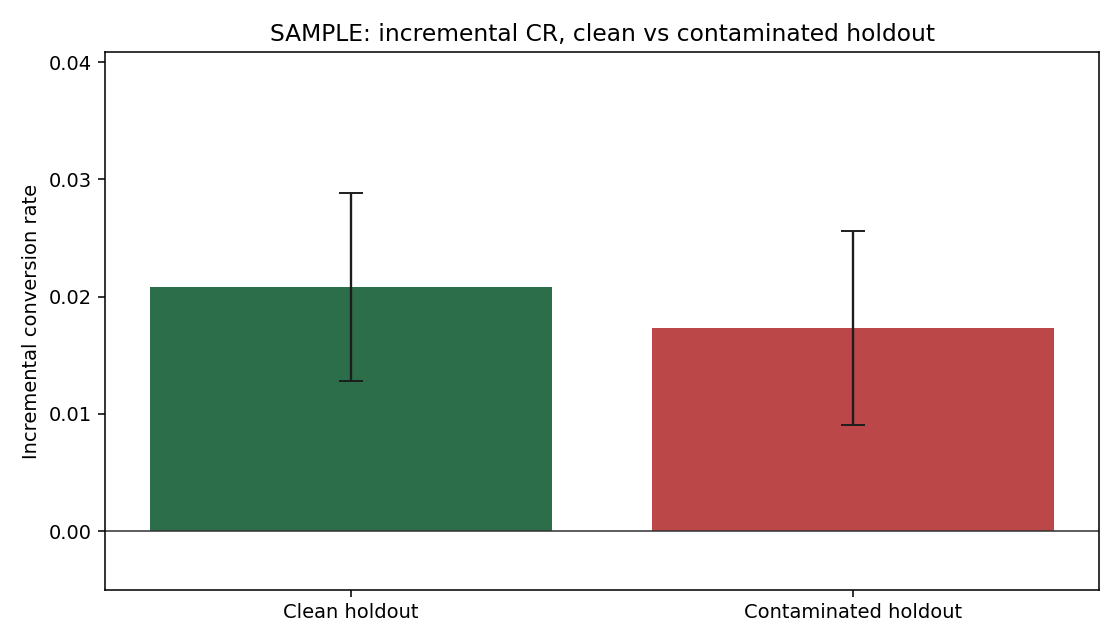

{'dataset': 'sends_contaminated.csv',
 'treated_n': 7200,
 'holdout_n': 4800,
 'treated_sent_rate': 0.7777777777777778,
 'holdout_sent_rate': 0.15,
 'treated_cr': 0.06375,
 'holdout_cr': 0.04645833333333333,
 'treated_cr_wilson_low': 0.058336144798167906,
 'treated_cr_wilson_high': 0.069629134171875,
 'holdout_cr_wilson_low': 0.040857980855708846,
 'holdout_cr_wilson_high': 0.052784074286159284,
 'incremental_cr': 0.01729166666666667,
 'incremental_cr_ci_low': 0.00902777777777778,
 'incremental_cr_ci_high': 0.025555555555555554,
 'ci_method': 'bootstrap_percentile_B2000_seed2020',
 'treated_revenue': 23961.65,
 'holdout_revenue': 10935.81,
 'treated_rev_per_user': 3.3280069444444447,
 'holdout_rev_per_user': 2.27829375,
 'incremental_rev_per_user': 1.0497131944444447}

In [6]:
dirty = lift_metrics(dirty_df, "sends_contaminated.csv")
print("holdout sent-rate clean vs dirty:", clean["holdout_sent_rate"], dirty["holdout_sent_rate"])
print("incremental CR clean vs dirty:", clean["incremental_cr"], dirty["incremental_cr"])
plot_lift(clean, dirty, OUT / "sample_incremental_cr.png")
display(Image(filename=str(OUT / "sample_incremental_cr.png")))
dirty

## Write the lift tables

These are the files the script also writes. Kill rule lives in the last cell.

In [7]:
import polars as pl

pl.DataFrame([clean]).write_csv(OUT / "clean_lift.csv")
pl.DataFrame([dirty]).write_csv(OUT / "contaminated_lift.csv")
paragraph = write_marketer(clean, dirty, cohort)
(OUT / "marketer.md").write_text(paragraph + "\n", encoding="utf-8")
print("wrote", OUT / "clean_lift.csv")
print("wrote", OUT / "contaminated_lift.csv")
print("wrote", OUT / "marketer.md")

wrote /Users/martysmithson/Documents/Job Search/08 Proof/marketing-measurement-proof/05-hightouch-eda/out/clean_lift.csv
wrote /Users/martysmithson/Documents/Job Search/08 Proof/marketing-measurement-proof/05-hightouch-eda/out/contaminated_lift.csv
wrote /Users/martysmithson/Documents/Job Search/08 Proof/marketing-measurement-proof/05-hightouch-eda/out/marketer.md


In [8]:
print(Path("out/marketer.md").read_text(encoding="utf-8"))

I would not ship this send.

On the clean holdout, the email looks incremental: treated conversion rate 6.38% vs holdout 4.29%, incremental CR 2.08% (95% bootstrap CI 1.28% to 2.88%) on a 4-week window. That is the number I would take to a marketer if the holdout were a holdout.

It is not. In the contaminated file, 15% of users with holdout_flag=1 still have sent=1 — they actually received the email. Holdout CR rises from 4.29% to 4.65% and incremental CR collapses from 2.08% to 1.73% (CI 0.90% to 2.56%). The creative did not get worse. The counterfactual got polluted.

Kill rule: if send rate among holdout_flag=1 is above 1%, stop. Do not scale. Do not retune the agent. Fix suppression and assignment, then rerun. A smaller lift on a dirty holdout is not evidence the campaign should stay on; it is evidence you can no longer measure it. Even on the clean file, most incremental cash sits in cohort 2024-01-01 — I would not turn this into always-on without a replicate on a later cohort.

